# PCD Assignment 02 — Image Enhancement

**Course:** Pengolahan Citra Digital (Digital Image Processing)

This notebook enhances three **real degraded photographs downloaded from the internet**, one for each of
three common image problems, using one enhancement method per problem:

| # | Image problem | Enhancement method |
|---|---------------|--------------------|
| 2 | **Dark** (low-light) image | Gamma correction |
| 3 | **Blurred** image | Richardson–Lucy deconvolution |
| 4 | **Noisy** image | Non-local means (NL-means) denoising |

Because these are real photographs, there is no clean "ground-truth" version to compare with, so the
results are judged visually and with **no-reference measures**: mean brightness, standard deviation
(contrast), Shannon entropy (information), variance of the Laplacian (sharpness) and the estimated noise
standard deviation σ.

## 0. Setup and helper functions

In [1]:
import warnings
warnings.filterwarnings("ignore")

import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage import color, restoration, img_as_float
from skimage.measure import shannon_entropy

plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 11, "savefig.bbox": "tight"})

DIR_IN, DIR_OUT, DIR_FIG = Path("images/input"), Path("images/enhanced"), Path("images/figures")
for d in (DIR_IN, DIR_OUT, DIR_FIG):
    d.mkdir(parents=True, exist_ok=True)

def to_u8(img):
    return (np.clip(img, 0, 1) * 255 + 0.5).astype(np.uint8)

def to_gray(img):
    return color.rgb2gray(img) if img.ndim == 3 else img

def load(path):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    return img_as_float(img)

def save(img, path):
    cv2.imwrite(str(path), cv2.cvtColor(to_u8(img), cv2.COLOR_RGB2BGR))

def measure(img):
    '''No-reference quality measures.'''
    g = to_gray(img)
    return {"Mean (brightness)": g.mean(),
            "Std (contrast)": g.std(),
            "Entropy (bits)": shannon_entropy(to_u8(g)),
            "Sharpness (Laplacian var.)": cv2.Laplacian(to_u8(g), cv2.CV_64F).var(),
            "Noise σ (estimated)": np.mean(restoration.estimate_sigma(img, channel_axis=-1))}

def compare(before, after):
    return pd.DataFrame({"Before": measure(before), "After": measure(after)}).round(4)

def show_before_after(before, after, title, fname, zoom=None, hist=False):
    rows = 2 if hist else 1
    h, w = before.shape[:2]
    fig, ax = plt.subplots(rows, 2, figsize=(11, 5.5 * h / w + (2 if hist else 0) + 0.6), squeeze=False,
                           gridspec_kw={"height_ratios": [5.5 * h / w, 1.6] if hist else [1]})
    for i, (name, img) in enumerate((("Before", before), ("After", after))):
        ax[0, i].imshow(img); ax[0, i].set_title(name); ax[0, i].axis("off")
        if hist:
            ax[1, i].hist(to_u8(to_gray(img)).ravel(), bins=64, range=(0, 255), color="#4C72B0")
            ax[1, i].set_xlim(0, 255); ax[1, i].set_yticks([]); ax[1, i].set_xlabel("intensity")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); fig.savefig(DIR_FIG / fname, dpi=110); plt.show()
    if zoom is not None:                                         # close-up of a detail
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        for i, (name, img) in enumerate((("Before (zoom)", before), ("After (zoom)", after))):
            ax[i].imshow(img[zoom]); ax[i].set_title(name); ax[i].axis("off")
        plt.tight_layout(); fig.savefig(DIR_FIG / fname.replace(".png", "_zoom.png"), dpi=110); plt.show()

## 1. Test images (real photographs from the internet)

The three images are real degraded photographs from public image datasets hosted on GitHub. They are
downloaded from the URLs below the first time the notebook runs and stored unchanged in `images/input/`.

| Problem | Image | Source | Credit |
|---|---|---|---|
| Dark | LIME `2.bmp` | LIME low-light dataset — X. Guo, Y. Li, H. Ling, *"LIME: Low-Light Image Enhancement via Illumination Map Estimation"*, IEEE TIP 2017. File hosted in the [Zero-DCE repository](https://github.com/Li-Chongyi/Zero-DCE) | research dataset |
| Blurred | `fishes.jpg` | Real blurred images of D. Ren et al., *"Neural Blind Deconvolution Using Deep Priors"* (SelfDeblur), CVPR 2020 — [SelfDeblur repository](https://github.com/csdwren/SelfDeblur) | research test image |
| Noisy | RNI15 `Flowers.png` | RNI15 real-noise set — M. Lebrun, M. Colom, J.-M. Morel, *"The Noise Clinic"*, IPOL 2015. File hosted in the [FFDNet repository](https://github.com/cszn/FFDNet) | research test image |

dark     dark__LIME_2.bmp             560×420 px
blurred  blurred__fishes.jpg          858×558 px
noisy    noisy__RNI15_Flowers.png     500×375 px


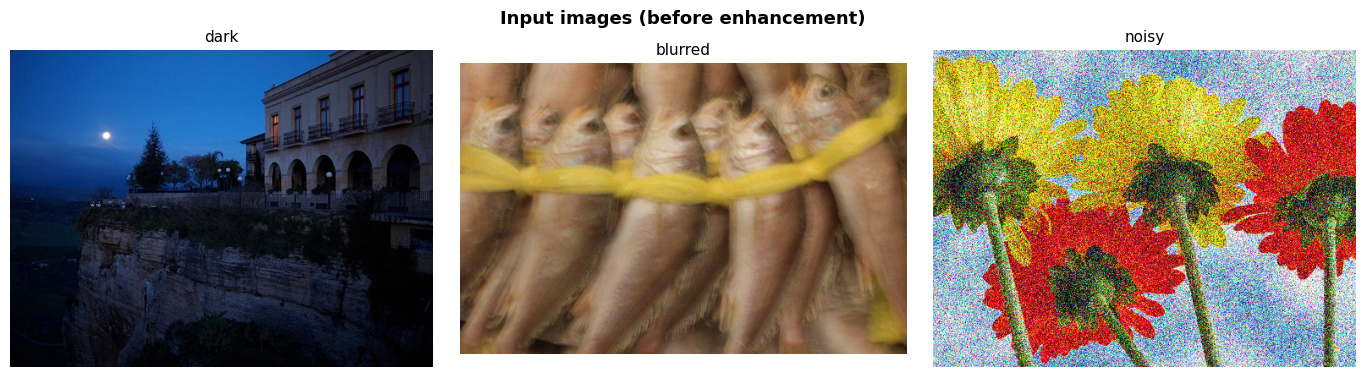

In [2]:
RAW = "https://raw.githubusercontent.com/"
SOURCES = {
    "dark":    ("dark__LIME_2.bmp",
                RAW + "Li-Chongyi/Zero-DCE/master/Zero-DCE_code/data/test_data/LIME/2.bmp"),
    "blurred": ("blurred__fishes.jpg",
                RAW + "csdwren/SelfDeblur/master/datasets/real/fishes.jpg"),
    "noisy":   ("noisy__RNI15_Flowers.png",
                RAW + "cszn/FFDNet/master/testsets/RNI15/Flowers.png"),
}
images = {}
for key, (fname, url) in SOURCES.items():
    path = DIR_IN / fname
    if not path.exists():
        print("downloading", url)
        urllib.request.urlretrieve(url, path)
    images[key] = load(path)
    print(f"{key:8s} {fname:28s} {images[key].shape[1]}×{images[key].shape[0]} px")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for i, (k, img) in enumerate(images.items()):
    ax[i].imshow(img); ax[i].set_title(k); ax[i].axis("off")
fig.suptitle("Input images (before enhancement)", fontsize=13, fontweight="bold")
plt.tight_layout(); fig.savefig(DIR_FIG / "00_inputs.png", dpi=110); plt.show()

## 2. Dark image → Gamma correction

A low-light image has most of its pixels at low intensities, so shadows and details are hidden.
**Gamma correction** is a point (pixel-by-pixel) transformation

$$ s = r^{\gamma}, \qquad r, s \in [0, 1] $$

With $\gamma < 1$ the curve lies above the line $s = r$: dark values are raised strongly while bright values
change little, so the shadows are brightened without saturating the highlights. The transform is applied
to the **L\* (lightness) channel of the CIELAB colour space**, so only brightness changes and the colours
(hue and saturation) are preserved.

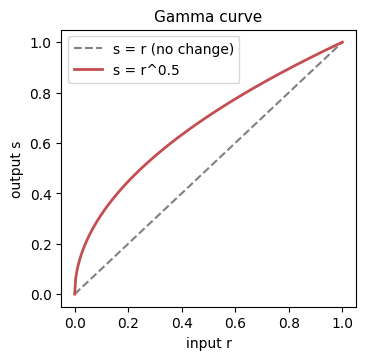

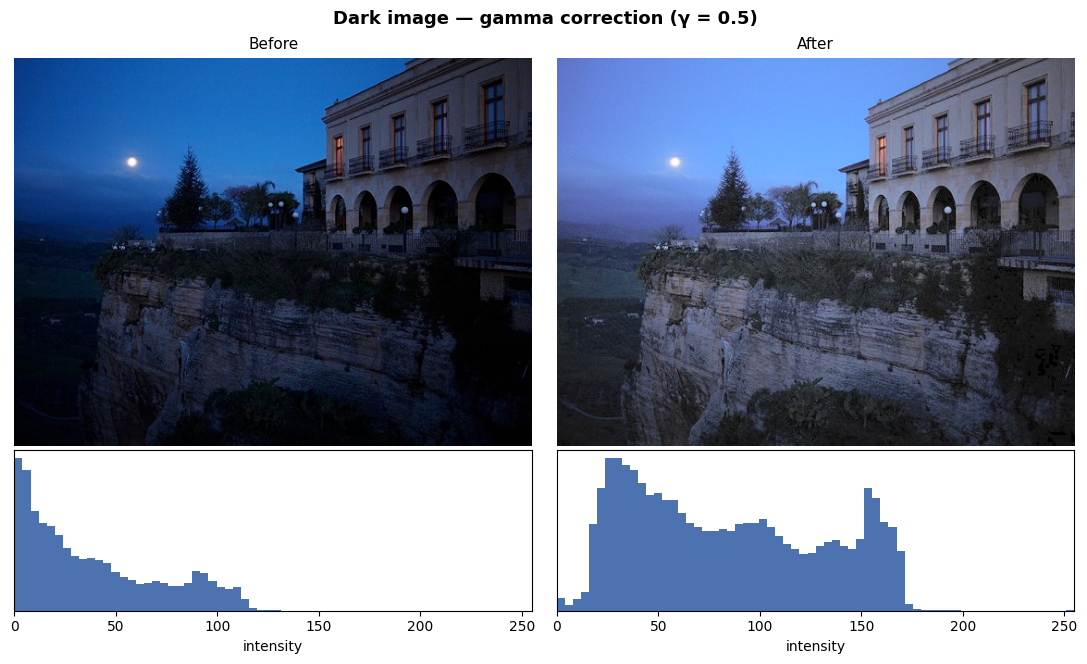

,Before,After
Mean (brightness),0.1522,0.3303
Std (contrast),0.1305,0.1854
Entropy (bits),6.5905,7.2590
Sharpness (Laplacian var.),350.0514,838.3720
Noise σ (estimated),0.0038,0.0061


In [3]:
def gamma_correction(img, gamma):
    '''Gamma correction on the L* channel of CIELAB (colours are preserved).'''
    lab = color.rgb2lab(img)
    L = lab[..., 0] / 100.0                     # L* in [0, 1]
    lab[..., 0] = np.power(L, gamma) * 100.0    # s = r^gamma
    return np.clip(color.lab2rgb(lab), 0, 1)

GAMMA = 0.5
dark = images["dark"]
dark_enh = gamma_correction(dark, GAMMA)
save(dark_enh, DIR_OUT / "dark__gamma_correction.png")

# the transformation curve
r = np.linspace(0, 1, 256)
plt.figure(figsize=(3.8, 3.6))
plt.plot(r, r, "--", color="gray", label="s = r (no change)")
plt.plot(r, r ** GAMMA, color="#C44E52", lw=2, label=f"s = r^{GAMMA}")
plt.xlabel("input r"); plt.ylabel("output s"); plt.legend(); plt.title("Gamma curve")
plt.savefig(DIR_FIG / "01_gamma_curve.png", dpi=110); plt.show()

show_before_after(dark, dark_enh, f"Dark image — gamma correction (γ = {GAMMA})", "01_dark.png", hist=True)
table_dark = compare(dark, dark_enh)
table_dark

**Analysis.** Gamma correction with γ = 0.5 reveals the cliff, the trees and the building facade, which were almost invisible in the input. The histogram, which was packed into the lowest intensities, is spread over a much wider range. The mean brightness more than doubles (0.152 → 0.330), and contrast (std 0.131 → 0.185) and entropy (6.59 → 7.26 bits) both increase, so more detail is visible. Because only L* is changed, the colours of the scene (the blue evening sky, the warm window lights) are kept. There are two limitations. First, brightening also makes the hidden sensor noise more visible (estimated σ 0.0038 → 0.0061). Second, pixels that were completely black (value 0) stay black, since 0<sup>γ</sup> = 0, so a few small dark specks remain in the deepest shadows. A smaller γ would brighten more, but it would make the image look flat and washed out.

## 3. Blurred image → Richardson–Lucy deconvolution

A blurred image can be modelled as the sharp image $f$ convolved with a **point-spread function** (PSF)
$h$, plus noise: $g = f * h + n$. **Richardson–Lucy (RL)** deconvolution estimates $f$ iteratively:

$$ f^{(k+1)} = f^{(k)} \cdot \left( \frac{g}{f^{(k)} * h} * \tilde h \right) $$

where $\tilde h$ is the PSF flipped. Each iteration compares the re-blurred estimate with the observed
image and corrects the estimate. For a real photograph the true PSF is unknown, so a **Gaussian PSF is
assumed** and its width σ is chosen by testing several values.

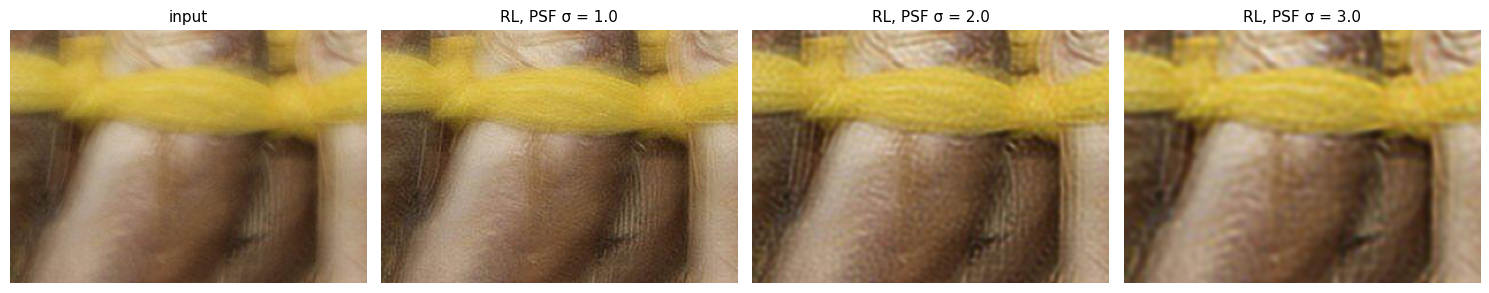

In [4]:
def gaussian_psf(sigma):
    size = int(6 * sigma) | 1
    ax = np.arange(size) - size // 2
    k = np.exp(-(ax[:, None] ** 2 + ax[None, :] ** 2) / (2 * sigma ** 2))
    return k / k.sum()

def richardson_lucy(img, psf, n_iter=20):
    '''RL deconvolution per colour channel (symmetric padding avoids border artefacts).'''
    p = psf.shape[0]
    out = [restoration.richardson_lucy(np.pad(img[..., c], p, mode="symmetric"), psf, num_iter=n_iter)[p:-p, p:-p]
           for c in range(3)]
    return np.clip(np.dstack(out), 0, 1)

blurred = images["blurred"]
zoom_b = np.s_[180:400, 250:560]

# choosing the PSF width: too small = little effect, too large = ringing artefacts
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
ax[0].imshow(blurred[zoom_b]); ax[0].set_title("input"); ax[0].axis("off")
for i, s in enumerate((1.0, 2.0, 3.0), start=1):
    ax[i].imshow(richardson_lucy(blurred, gaussian_psf(s))[zoom_b])
    ax[i].set_title(f"RL, PSF σ = {s}"); ax[i].axis("off")
plt.tight_layout(); fig.savefig(DIR_FIG / "02_psf_choice.png", dpi=110); plt.show()

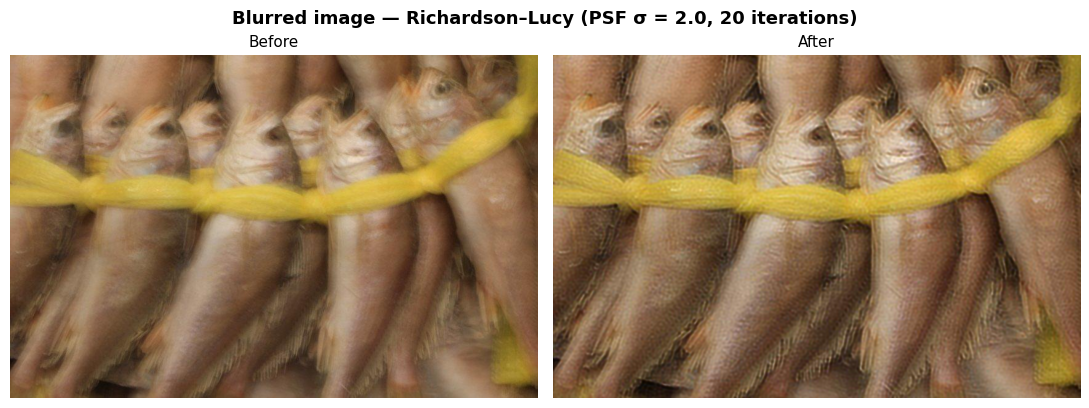

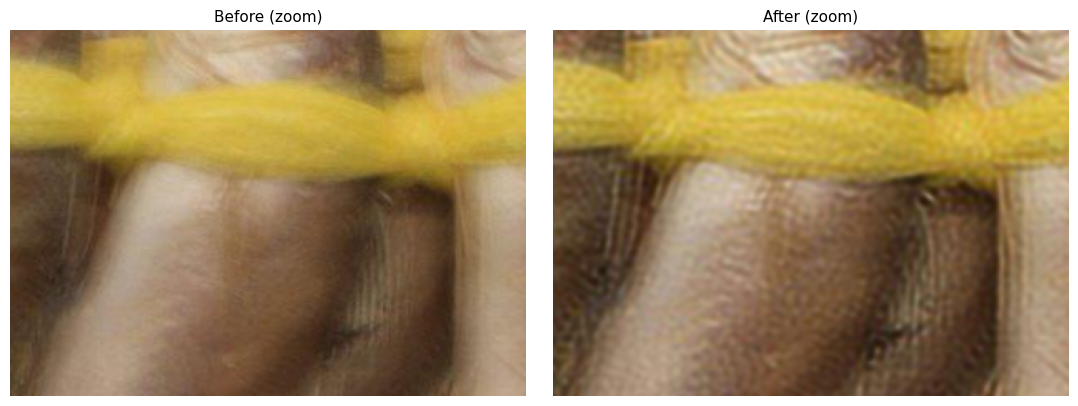

,Before,After
Mean (brightness),0.4502,0.4502
Std (contrast),0.1518,0.1552
Entropy (bits),7.2499,7.2942
Sharpness (Laplacian var.),37.7978,26.5909
Noise σ (estimated),0.0021,0.0008


In [5]:
PSF_SIGMA, N_ITER = 2.0, 20
blurred_enh = richardson_lucy(blurred, gaussian_psf(PSF_SIGMA), N_ITER)
save(blurred_enh, DIR_OUT / "blurred__richardson_lucy.png")

show_before_after(blurred, blurred_enh, f"Blurred image — Richardson–Lucy (PSF σ = {PSF_SIGMA}, {N_ITER} iterations)",
                  "02_blurred.png", zoom=zoom_b)
table_blurred = compare(blurred, blurred_enh)
table_blurred

**Analysis.** Richardson–Lucy deconvolution clearly sharpens the image. In the close-up, the individual fibres of the yellow string and the edges and texture of the fish become visible, while the input is smooth and smeared. The PSF test shows why σ = 2 was chosen: σ = 1 changes very little, while σ = 3 is too large for the real blur and starts to create ringing (repeated edge patterns). Contrast and entropy increase slightly (std 0.152 → 0.155, entropy 7.25 → 7.29 bits). Interestingly, the Laplacian-variance sharpness value decreases (38 → 27) and the estimated noise also falls (0.0021 → 0.0008). RL restores the mid-frequency edges that were blurred, but it also suppresses pixel-level noise and JPEG texture, which is exactly what the Laplacian measures. A simple sharpness number therefore does not always agree with what the eye sees, and visual inspection is necessary. The main limitation of the method is that the PSF must be known or guessed; a wrong PSF gives artefacts instead of detail.

## 4. Noisy image → Non-local means denoising

Simple smoothing filters (mean, Gaussian) average each pixel with its **neighbours**, which removes noise but
also blurs edges. **Non-local means** instead averages each pixel with pixels whose surrounding **patch looks
similar**, wherever they are in a search window:

$$ \hat f(p) = \frac{1}{Z(p)} \sum_{q} w(p,q)\, g(q), \qquad
   w(p,q) = \exp\!\left(-\frac{\lVert P(p) - P(q) \rVert^2}{h^2}\right) $$

$P(p)$ is the patch around pixel $p$ and $h$ controls the filtering strength. Because an edge is only averaged
with other similar edges, noise is removed while structures stay sharp. The noise level σ is estimated
from the image and $h$ is set proportional to it.

estimated noise σ = 0.232


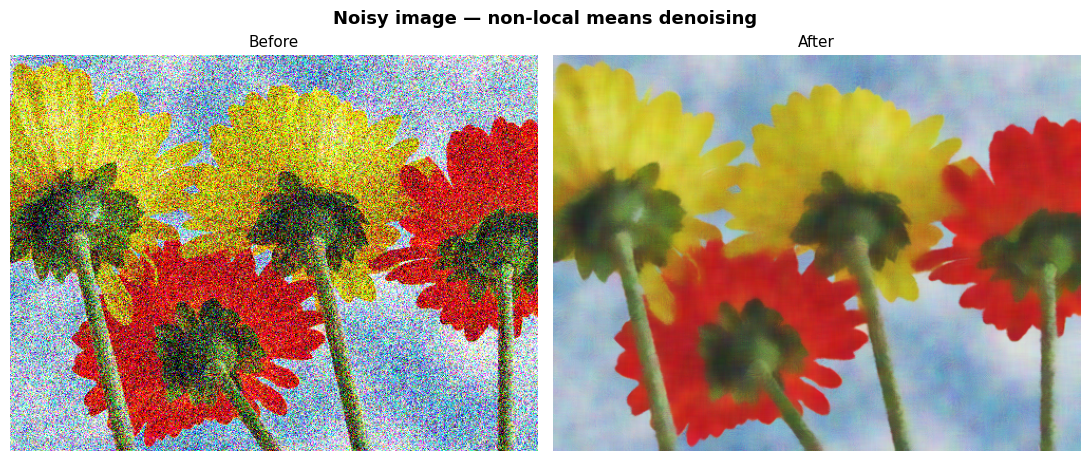

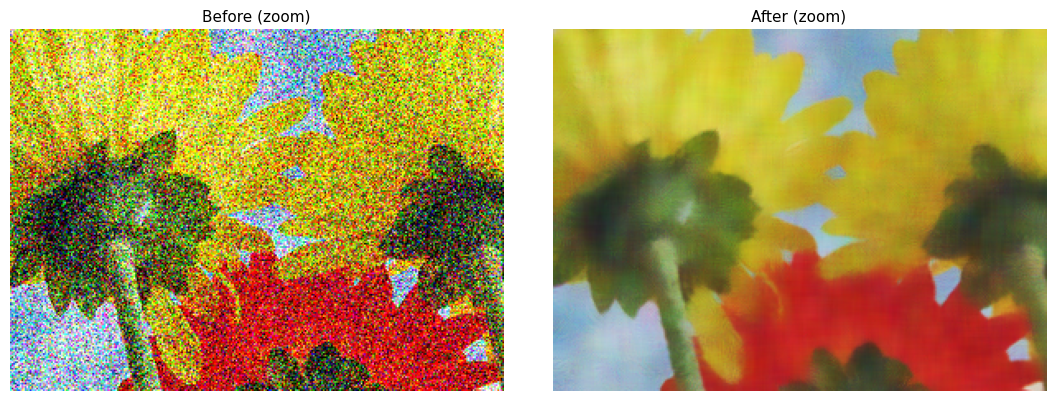

,Before,After
Mean (brightness),0.5407,0.5399
Std (contrast),0.2735,0.1962
Entropy (bits),7.9306,7.0608
Sharpness (Laplacian var.),45643.9209,149.3820
Noise σ (estimated),0.2322,0.0066


In [6]:
def nl_means(img, h_factor=0.8):
    sigma = np.mean(restoration.estimate_sigma(img, channel_axis=-1))     # estimated noise level
    out = restoration.denoise_nl_means(img, h=h_factor * sigma, sigma=sigma, patch_size=5,
                                       patch_distance=6, fast_mode=True, channel_axis=-1)
    return np.clip(out, 0, 1), sigma

noisy = images["noisy"]
noisy_enh, sigma_est = nl_means(noisy)
save(noisy_enh, DIR_OUT / "noisy__nl_means.png")
print(f"estimated noise σ = {sigma_est:.3f}")

show_before_after(noisy, noisy_enh, "Noisy image — non-local means denoising", "03_noisy.png",
                  zoom=np.s_[40:260, 0:300])
table_noisy = compare(noisy, noisy_enh)
table_noisy

**Analysis.** The input contains extremely strong real colour noise (estimated σ ≈ 0.23 on a 0–1 scale). Non-local means removes almost all of it: the estimated noise falls about 35× (0.232 → 0.0066). The sky becomes smooth, and the flowers and stems keep clear outlines, because each pixel is averaged only with pixels whose neighbourhood looks similar. The Laplacian variance falls from 45 644 to 149, which shows how much of the original 'detail' was only noise. The standard deviation (0.274 → 0.196) and entropy (7.93 → 7.06 bits) also decrease, because the random noise had artificially increased both. The price is that very fine texture, such as the thin lines on the petals, is smoothed away, giving a slightly painted look. This is unavoidable at such a high noise level, where the fine details are buried under the noise.

## 5. Summary

In [7]:
rows = []
for name, method, t in (("Dark", "Gamma correction (γ = 0.5)", table_dark),
                        ("Blurred", "Richardson–Lucy (PSF σ = 2)", table_blurred),
                        ("Noisy", "Non-local means", table_noisy)):
    row = {"Image": name, "Method": method}
    for m in t.index:
        row[m] = f'{t.loc[m, "Before"]:.3f} → {t.loc[m, "After"]:.3f}'
    rows.append(row)
summary = pd.DataFrame(rows).set_index("Image")
with open("results_tables.md", "w") as f:
    for n, t in (("dark", table_dark), ("blurred", table_blurred), ("noisy", table_noisy)):
        f.write(f"### {n}\n\n{t.to_markdown()}\n\n")
    f.write(f"### summary\n\n{summary.to_markdown()}\n")
summary

,Method,Mean (brightness),Std (contrast),Entropy (bits),Sharpness (Laplacian var.),Noise σ (estimated)
Image,,,,,,
Dark,Gamma correction (γ = 0.5),0.152 → 0.330,0.131 → 0.185,6.590 → 7.259,350.051 → 838.372,0.004 → 0.006
Blurred,Richardson–Lucy (PSF σ = 2),0.450 → 0.450,0.152 → 0.155,7.250 → 7.294,37.798 → 26.591,0.002 → 0.001
Noisy,Non-local means,0.541 → 0.540,0.274 → 0.196,7.931 → 7.061,45643.921 → 149.382,0.232 → 0.007


## 6. Conclusion

Each type of degradation needs its own method:

* **Dark image → gamma correction.** A simple, fast point operation that brightens shadows much more than highlights. Applied to the L* channel it preserves colour. Its drawbacks are that it also amplifies hidden noise and cannot recover pixels that are completely black.
* **Blurred image → Richardson–Lucy deconvolution.** Unlike simple sharpening filters, it models the blur and inverts it, so it recovers real edges and texture. It depends on the point-spread function, which for a real photo has to be estimated; a wrong PSF produces ringing.
* **Noisy image → non-local means.** It averages similar patches instead of neighbouring pixels, so it removes very strong noise while keeping edges. Very fine texture is lost when the noise is heavy.

For real photographs no clean reference exists, so the results were judged visually and with no-reference measures (brightness, contrast, entropy, sharpness, estimated noise). These measures are useful, but they can disagree with visual quality: the deblurred image, for example, has a lower Laplacian variance although it looks sharper.